In [8]:
from langgraph.graph import StateGraph,START,END;

from typing import Annotated,TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_core.messages import AIMessage,BaseMessage,HumanMessage,SystemMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver

load_dotenv()

True

In [9]:
class JokeState(TypedDict):
    joke: str
    explanation:str
    topic:str

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",max_tokens=1000)

def generate_joke(state:JokeState):
    prompt = f"Generate a joke about {state['topic']} and explain it in a funny way."
    response = llm.invoke(prompt)

    return{'joke':response.content}

def generate_explanation(state:JokeState):
    prompt = f"Explain the joke: {state['joke']} in a humorous way."
    response = llm.invoke(prompt)

    return{'explanation':response.content}

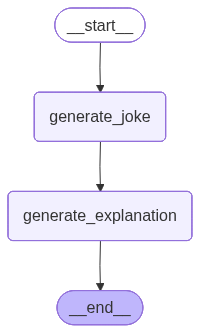

In [10]:
graph=StateGraph(JokeState)

graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer=InMemorySaver()

# ? we will pass checkpointer to the graph so that it can save the state of the graph after each node execution
workflow=graph.compile(checkpointer=checkpointer)

workflow


In [11]:
config1={"configurable":{"thread_id":1}}

workflow.invoke({"topic":"pizza"},config=config1)


{'joke': [{'type': 'text',
   'text': 'Here is your pizza joke, followed by an over-analytical, slightly dramatic explanation.\n\n***\n\n### The Joke:\n\nI went to a pizzeria yesterday and ordered a whole pepperoni pie. The guy behind the counter asked, **"Do you want me to cut it into 8 slices or 12?"**\n\nI shook my head and said, **"Oh, definitely 8. There is no way I could eat 12 slices!"**\n\n***\n\n### The "Funny" Explanation:\n\nNow, let us dissect this comedic masterpiece with the seriousness of a high',
   'extras': {'signature': 'Es8aCswaAQw51sdD4rdWdjuvhsdf2ikSYAQ4dyd1UtbTy6j+qssxk5fg8r3hzoo5je8JGUTxXMux053m8Lx9VzDiU0wltF31WesFo2Nazr11rwEMUcj5B5qOeRR6VIveD/wTZUvT3tby34rZJs2cFOzPLFNOrHXyy7Vt1MjncCPBiy00Jkcj/Uxl+w4f1PCkoA+UpWU371Y5CiP1gECS+76tfbiZIwTFmNoS6ejE1eBuXL+dUsy1ciI0ORmi1mmiSQlrWKAL52/aLCB4ejzRsIrTHYZ+PpkmO3Y2uRVZKv8ErPw/Aqq5I6st/hB3NTHIUXqZSkNQ5rjHU/eOfUIiHqWLdyko6zMotV3YSsW5fN4VZuxt70dSwoeZUFPuwvrT0APY3oIZjwD7vnZ0hdahKchgx+VaFEDf4/Xg4ojx8wZxiSAj1IUVVtQnNLW/+84+cIoQMx

In [12]:
workflow.get_state(config=config1) # * we can use the get_state function to get the state of the graph for a specific conversation thread, so that we can continue the conversation later

StateSnapshot(values={'joke': [{'type': 'text', 'text': 'Here is your pizza joke, followed by an over-analytical, slightly dramatic explanation.\n\n***\n\n### The Joke:\n\nI went to a pizzeria yesterday and ordered a whole pepperoni pie. The guy behind the counter asked, **"Do you want me to cut it into 8 slices or 12?"**\n\nI shook my head and said, **"Oh, definitely 8. There is no way I could eat 12 slices!"**\n\n***\n\n### The "Funny" Explanation:\n\nNow, let us dissect this comedic masterpiece with the seriousness of a high', 'extras': {'signature': 'Es8aCswaAQw51sdD4rdWdjuvhsdf2ikSYAQ4dyd1UtbTy6j+qssxk5fg8r3hzoo5je8JGUTxXMux053m8Lx9VzDiU0wltF31WesFo2Nazr11rwEMUcj5B5qOeRR6VIveD/wTZUvT3tby34rZJs2cFOzPLFNOrHXyy7Vt1MjncCPBiy00Jkcj/Uxl+w4f1PCkoA+UpWU371Y5CiP1gECS+76tfbiZIwTFmNoS6ejE1eBuXL+dUsy1ciI0ORmi1mmiSQlrWKAL52/aLCB4ejzRsIrTHYZ+PpkmO3Y2uRVZKv8ErPw/Aqq5I6st/hB3NTHIUXqZSkNQ5rjHU/eOfUIiHqWLdyko6zMotV3YSsW5fN4VZuxt70dSwoeZUFPuwvrT0APY3oIZjwD7vnZ0hdahKchgx+VaFEDf4/Xg4ojx8wZxiSAj1IUVVtQ

In [13]:
list(workflow.get_state_history(config=config1)) # ? we can use the get_state_history function to get the state history of the graph for a specific conversation thread, so that we can continue the conversation later

[StateSnapshot(values={'joke': [{'type': 'text', 'text': 'Here is your pizza joke, followed by an over-analytical, slightly dramatic explanation.\n\n***\n\n### The Joke:\n\nI went to a pizzeria yesterday and ordered a whole pepperoni pie. The guy behind the counter asked, **"Do you want me to cut it into 8 slices or 12?"**\n\nI shook my head and said, **"Oh, definitely 8. There is no way I could eat 12 slices!"**\n\n***\n\n### The "Funny" Explanation:\n\nNow, let us dissect this comedic masterpiece with the seriousness of a high', 'extras': {'signature': 'Es8aCswaAQw51sdD4rdWdjuvhsdf2ikSYAQ4dyd1UtbTy6j+qssxk5fg8r3hzoo5je8JGUTxXMux053m8Lx9VzDiU0wltF31WesFo2Nazr11rwEMUcj5B5qOeRR6VIveD/wTZUvT3tby34rZJs2cFOzPLFNOrHXyy7Vt1MjncCPBiy00Jkcj/Uxl+w4f1PCkoA+UpWU371Y5CiP1gECS+76tfbiZIwTFmNoS6ejE1eBuXL+dUsy1ciI0ORmi1mmiSQlrWKAL52/aLCB4ejzRsIrTHYZ+PpkmO3Y2uRVZKv8ErPw/Aqq5I6st/hB3NTHIUXqZSkNQ5rjHU/eOfUIiHqWLdyko6zMotV3YSsW5fN4VZuxt70dSwoeZUFPuwvrT0APY3oIZjwD7vnZ0hdahKchgx+VaFEDf4/Xg4ojx8wZxiSAj1IUVVt

# Time Travel

In [ ]:
workflow.get_state(config={"configurable":{"thread_id":1,"checkpoint_id":"1f169a19-8d59-647e-8000-c48e038a07ad"}})
# ? we can time travel to get to a particular state and start our execution from that point only

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f169a19-8d59-647e-8000-c48e038a07ad'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-06-16T16:36:59.998095+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f169a19-8d54-60c5-bfff-310fc2b99f7d'}}, tasks=(PregelTask(id='74035233-4e5a-227f-b300-87506ee3c888', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': [{'type': 'text', 'text': 'Here is your pizza joke, followed by an over-analytical, slightly dramatic explanation.\n\n***\n\n### The Joke:\n\nI went to a pizzeria yesterday and ordered a whole pepperoni pie. The guy behind the counter asked, **"Do you want me to cut it into 8 slices or 12?"**\n\nI shook my head and said, **"Oh, definitely 8. There is no way I could eat 12 slices!"**\n\n***\n\n### The "Funny" Explanati

In [ ]:
workflow.invoke(None,config={"configurable":{"thread_id":1,"checkpoint_id":"1f169a19-8d59-647e-8000-c48e038a07ad"}})

# ? in initial state pass none and in configuration pass checkpoint_id alsong with thread_id and will start execution from there

{'joke': [{'type': 'text',
   'text': 'Here is the joke, followed by an overly analytical (and hopefully funny) explanation.\n\n***\n\n### The Joke:\n**"I was going to tell you a joke about pizza, but it’s just too *cheesy*. And honestly? I was worried I wouldn\'t get the *delivery* right."**\n\n***\n\n### The Explanation (for people who like their jokes dissected like a frog in biology class):\n\nPlease, hold your applause. I know your mind is currently blown by this masterclass in culinary-comedy fusion. Let us dissect this humor-carcass piece by piece, so we can ruin the fun completely.\n\nThis joke is a rare "Double-Decker Pun-Tastic Supreme," leveraging two distinct linguistic homophones to attack your funny bone. \n\n**Part 1: The "Cheesy" Dilemma**\nFirst, we have the word **"cheesy."** \n*   **In the pizza world:** Cheese is the coagulated milk protein that binds the sauce to the crust, acting as a delicious, high-calorie blanket of joy. \n*   **In the comedy world:** "Cheesy" 

In [ ]:
workflow.update_state(config={"configurable":{"thread_id":1,"checkpoint_id":"1f169a19-8d59-647e-8000-c48e038a07ad"}},values={"joke":'test'})
# ? we can update the state of the graph for a specific conversation thread, and continue our execution with that updates state